In [71]:
# Teste do Jupyter
print("Código no Jupyter - Deve Aparecer o texto logo depois")

Código no Jupyter - Deve Aparecer o texto logo depois


In [72]:
# Tech Challenge FIAP — Fase 2
## Projeto 1 — Otimização de Modelos de Diagnóstico para Saúde da Mulher

# **Aluno:** Nelson Seiji  
# **Objetivo do notebook:** construir a base do modelo preditivo que será otimizado posteriormente com algoritmo genético.


In [73]:
# Biblioteca para trabalhar com dados em forma de tabela "PANel DAta"
# pd apelido da biblioteca
import pandas as pd

# Le um arquivo CSV e transforma em tabela pandas
# df - Data Frame
df = pd.read_csv("../data/breast-cancer-wisconsin-data-set.csv")

# Cria uma tupla com dois valores e pede para o Jupyter mostrar
# Shape - tamanho da tabela, linhas e colunas
# Columns - nomes das colunas
df.shape,df.columns

((569, 33),
 Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
        'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
        'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
        'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
        'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
        'fractal_dimension_se', 'radius_worst', 'texture_worst',
        'perimeter_worst', 'area_worst', 'smoothness_worst',
        'compactness_worst', 'concavity_worst', 'concave points_worst',
        'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
       dtype='str'))

In [74]:
# Apenas colunas
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')

In [75]:
# EDA - Exploratory Data Analysis
# Usar display para mostrar todas em uma mesma célula

# primeiras linhas
display(df.head())


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [76]:
# Tipos de dados e valores faltantes / numéricas e se há NaN
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [77]:
# estatísticas básicas - escalas, outliers
df.describe()   

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [78]:
# Valores Ausentes

# isnull() retorna True para cada célula ausente (NaN) e False caso contrário
# sum() soma os True como 1, então temos a quantidade de valores ausentes por coluna
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

# mean() em colunas booleanas dá a proporção de True
# Multiplicamos por 100 para ver a porcentagem de ausências
missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values(by="missing_count", ascending=False)

# DataFrame só para visualizar melhor os resultados
display(missing_df)

,missing_count,missing_percent
Unnamed: 32,569,100.0
id,0,0.0
diagnosis,0,0.0
texture_mean,0,0.0
radius_mean,0,0.0
area_mean,0,0.0
smoothness_mean,0,0.0
compactness_mean,0,0.0
perimeter_mean,0,0.0
concave points_mean,0,0.0


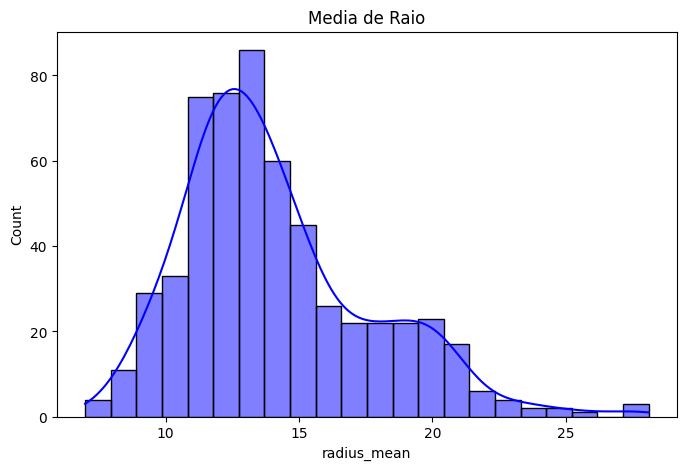

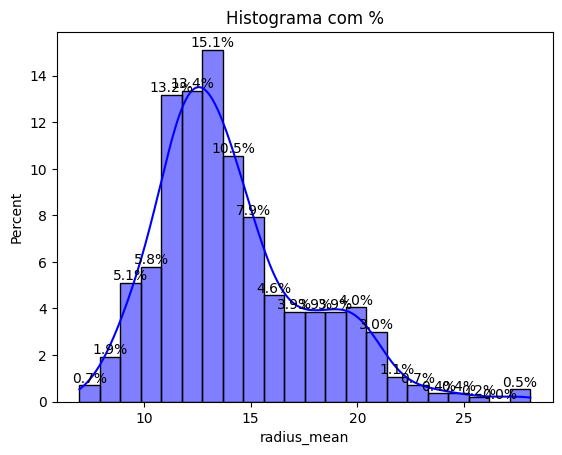

In [79]:
# DATAVIS
# Biblioteca base para criar gráficos
import matplotlib.pyplot as plt 

# Biblioteca construída sobre o matplotlib para gráficos estatísticos mais bonitos
import seaborn as sns           

# Distribuição da idade dos pacientes
# largura e altura em polegadas
plt.figure(figsize=(8, 5)) 

# Função histograma, dados=df, eixo x = coluna 'Age', kde = Kernel Density Estimate - linha, cor azul
sns.histplot(data=df, x='radius_mean', kde=True, color='blue')
plt.title('Media de Raio')  # Título do gráfico
plt.show()  # Comando final para mostrar o gráfico

# Função histograma, dados=df, eixo x = coluna 'Age', kde = Kernel Density Estimate - linha, cor azul
grafico_percent = sns.histplot(data=df, x='radius_mean', kde=True, color='blue', stat='percent')

# Adicionar rótulos nas barras
for container in grafico_percent.containers:
    grafico_percent.bar_label(container, fmt='%.1f%%') # Formata com 1 casa decimal e símbolo %

plt.title('Histograma com %')  # Título do gráfico
plt.show()  # Comando final para mostrar o gráfico

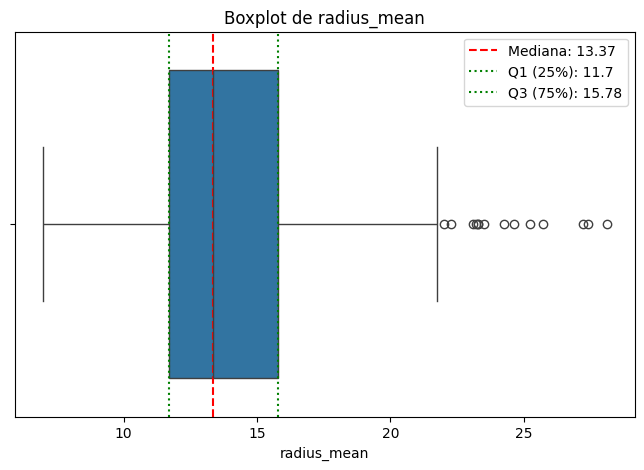

In [80]:
# Exemplo: Boxplot para nível de Raio
plt.figure(figsize=(8, 5))

# x - horizontal, regua de valores embaixo, analisa coluna radius_mean e faz distribuição
# Início da caixa (25%) - linha do meio (Mediana - 50%) - fim da caixa (75%)

sns.boxplot(x=df['radius_mean'])
plt.title('Boxplot de radius_mean')
#plt.show()

# Calcular valores estatísticos
# Pega o valor de radius_mean referente ao primeiro quartil, 25% dos primeiros valores (se fosse 0.99 os 1% mais altos)
q1 = df['radius_mean'].quantile(0.25)
mediana = df['radius_mean'].median()
q3 = df['radius_mean'].quantile(0.75)

# Adicionar linhas
# Axis Vertical Line - linha da Mediana, vermelha, tracejada, label na legenda
plt.axvline(mediana, color='red', linestyle='--', linewidth=1.5, label=f'Mediana: {mediana}')
# Axis Vertical Line - linhas dos Quartis, verde, pontihada, label na legenda
plt.axvline(q1, color='green', linestyle=':', linewidth=1.5, label=f'Q1 (25%): {q1}')
plt.axvline(q3, color='green', linestyle=':', linewidth=1.5, label=f'Q3 (75%): {q3}')
# Inserir legenda
plt.legend() # Mostra a legenda das linhas
plt.show()
 
# Caixa - entre Q1 e Q3, IQR - Interquartile Range - quanto maior a caixa mais dispersão no centro dos dados
# IQR = Q3 - Q1 = 140 - 99 = 41 
# Limite Inferior - Q1 - 1,5 x IQR = 99 - 1,5 x 41 = 38,5 / Limite Superior - Q3 + 1,5 x IQR = 140 + 1,5 x 41 = 200,5
# Bigodes - linhas fora da caixa - maior e menor valor não considerando outliers, limites
# Circulo (0) - outliers estatísticos, considerando 1,5 x IQR para mais ou para menos - pode descartar ou não 

Contagem absoluta das classes:


diagnosis
B    357
M    212
Name: count, dtype: int64


Proporção das classes:


diagnosis
B    0.6274
M    0.3726
Name: proportion, dtype: float64

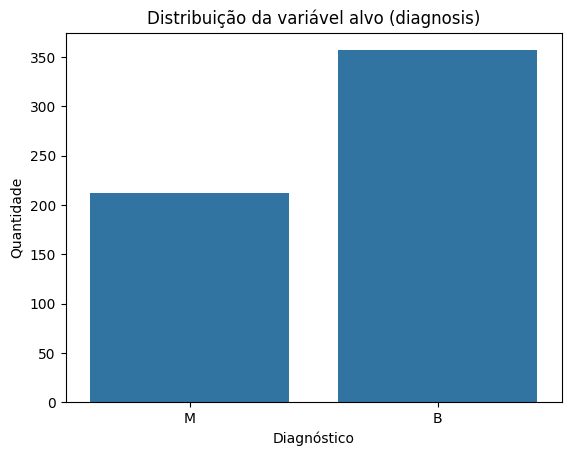

In [81]:
# Análise de Variável Alvo (Target)

# "diagnosis" - indica se tumor foi classificado como:
# M = malignant (maligno)
# B = benign (benigno)

# Biblioteca base para criar gráficos
import matplotlib.pyplot as plt 

# Biblioteca construída sobre o matplotlib para gráficos estatísticos mais bonitos
import seaborn as sns  

target_col = "diagnosis"

print("Contagem absoluta das classes:")
display(df[target_col].value_counts())

print("\nProporção das classes:")
display(df[target_col].value_counts(normalize=True).round(4))

# Gráfico de barras para visualizar melhor a distribuição
sns.countplot(data=df, x=target_col)
plt.title("Distribuição da variável alvo (diagnosis)")
plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade")
plt.show()

In [82]:
# Dataset desbalanceado, 63% benigno

In [83]:
# Limpeza Inicial da Base

# Cópia para preservar a base original
df_clean = df.copy()

# Remover colunas que não devem entrar no modelo:
# - "id" -> identificador, não representa característica clínica
# - "Unnamed: 32" -> coluna vazia / lixo de importação
cols_to_drop = ["id", "Unnamed: 32"]

df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")

print("Shape original:", df.shape)
print("Shape após limpeza inicial:", df_clean.shape)

print("\nColunas restantes:")
for coluna in df_clean.columns:
    print("-", coluna)

Shape original: (569, 33)
Shape após limpeza inicial: (569, 31)

Colunas restantes:
- diagnosis
- radius_mean
- texture_mean
- perimeter_mean
- area_mean
- smoothness_mean
- compactness_mean
- concavity_mean
- concave points_mean
- symmetry_mean
- fractal_dimension_mean
- radius_se
- texture_se
- perimeter_se
- area_se
- smoothness_se
- compactness_se
- concavity_se
- concave points_se
- symmetry_se
- fractal_dimension_se
- radius_worst
- texture_worst
- perimeter_worst
- area_worst
- smoothness_worst
- compactness_worst
- concavity_worst
- concave points_worst
- symmetry_worst
- fractal_dimension_worst


In [84]:
# Rótulos Textuais para EDA

# Converter a variável alvo para 0 e 1
# Nova coluna auxiliar apenas para visualização para gráficos e tabelas mais legíveis

df_clean["diagnosis_label"] = df_clean["diagnosis"].map({
    "B": "Benigno",
    "M": "Maligno"
})

print("Valores únicos em diagnosis_label:")
print(df_clean["diagnosis_label"].unique())

Valores únicos em diagnosis_label:
<StringArray>
['Maligno', 'Benigno']
Length: 2, dtype: str


In [85]:
# Converter alvo para binário
# B -> 0
# M -> 1

df_clean["diagnosis"] = df_clean["diagnosis"].map({
    "B": 0,
    "M": 1
})

print("Valores únicos após conversão:")
print(df_clean["diagnosis"].unique())

print("\nContagem após conversão:")
display(df_clean["diagnosis"].value_counts())

Valores únicos após conversão:
[1 0]

Contagem após conversão:


diagnosis
0    357
1    212
Name: count, dtype: int64

In [86]:
# Separação Features e Target

# X = variáveis de entrada
# y = variável alvo

# coluna diagnosis_label  auxiliar para visualização, não entra no modelo
X = df_clean.drop(columns=["diagnosis", "diagnosis_label"])
y = df_clean["diagnosis"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

print("\nPrimeiras linhas de X:")
display(X.head())

print("\nPrimeiras linhas de y:")
display(y.head())

print("Tipos de dados das colunas em X:")
display(X.dtypes)

Shape de X: (569, 30)
Shape de y: (569,)

Primeiras linhas de X:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Primeiras linhas de y:


0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

Tipos de dados das colunas em X:


radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst       float64
symmetry_worst      

In [87]:
# Lista de Features Numéricas

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Quantidade de features numéricas:", len(numeric_features))
print("\nLista das features:")
for col in numeric_features:
    print("-", col)

Quantidade de features numéricas: 30

Lista das features:
- radius_mean
- texture_mean
- perimeter_mean
- area_mean
- smoothness_mean
- compactness_mean
- concavity_mean
- concave points_mean
- symmetry_mean
- fractal_dimension_mean
- radius_se
- texture_se
- perimeter_se
- area_se
- smoothness_se
- compactness_se
- concavity_se
- concave points_se
- symmetry_se
- fractal_dimension_se
- radius_worst
- texture_worst
- perimeter_worst
- area_worst
- smoothness_worst
- compactness_worst
- concavity_worst
- concave points_worst
- symmetry_worst
- fractal_dimension_worst


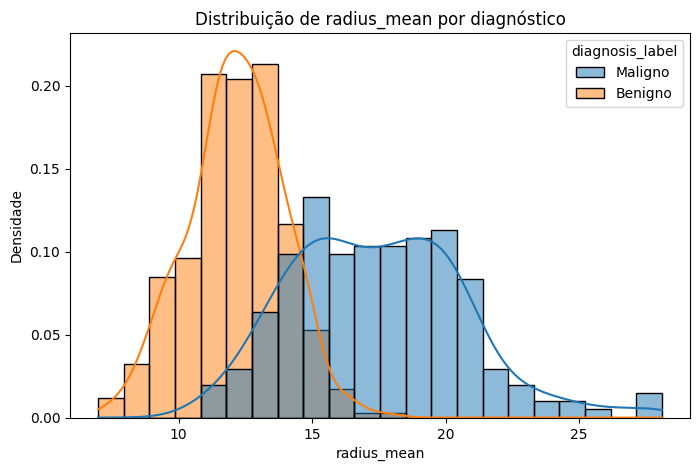

In [88]:
# Histograma comparando Benigno e Maligno
# mostra se a variável ajuda a separar as classes

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="radius_mean",
    hue="diagnosis_label",
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribuição de radius_mean por diagnóstico")
plt.xlabel("radius_mean")
plt.ylabel("Densidade")
plt.show()

In [89]:
# Benignos concentrados em radius_mean 10 a 13, malignos com patamar entre 15 e 20
# Aparentemente esta variável apresenta grande peso no diagnóstico

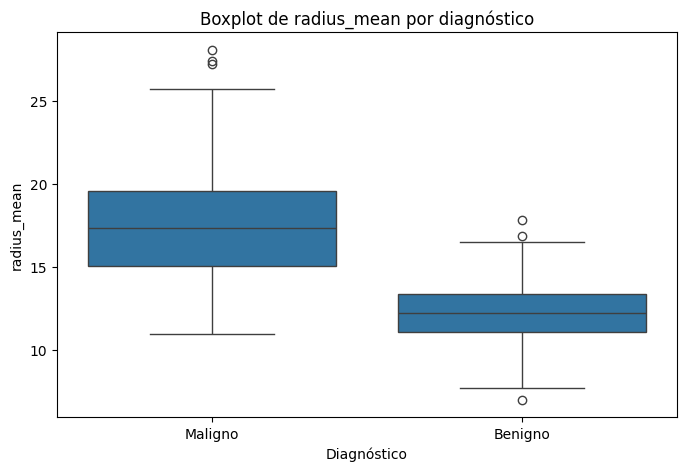

In [90]:
# Boxplot de radius_mean por diagnóstico

# Esse gráfico costuma ser mais informativo do que o boxplot 
# mostra como a variável se comporta em benignos e malignos

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="diagnosis_label",
    y="radius_mean"
)

plt.title("Boxplot de radius_mean por diagnóstico")
plt.xlabel("Diagnóstico")
plt.ylabel("radius_mean")
plt.show()

In [91]:
# Gráfico boxplot mostra mediana maior para Maligno
# Tumores malignos podem ser maiores e com maior variação no radius_mean

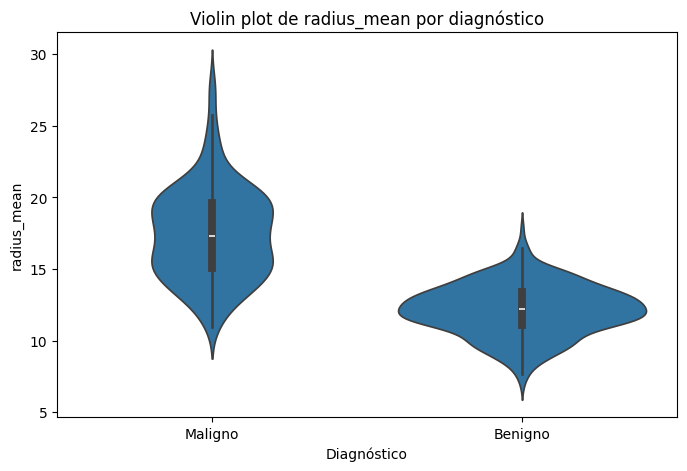

In [92]:
# Violin plot de radius_mean por diagnóstico

# combina boxplot com forma da distribuição, mostra densidade dos valores em cada grupo

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df_clean,
    x="diagnosis_label",
    y="radius_mean"
)

plt.title("Violin plot de radius_mean por diagnóstico")
plt.xlabel("Diagnóstico")
plt.ylabel("radius_mean")
plt.show()

In [93]:
# Violin plot mostra benigno com maior concentração e maligno com mais variação de radius_mean

In [94]:
# Estatísticas descritivas por grupo

# Aqui comparamos as estatísticas de uma variável separadas por diagnóstico.
# Isso ajuda a entender se a feature assume comportamentos diferentes nas classes.

estatisticas_grupo = df_clean.groupby("diagnosis_label")["radius_mean"].describe()

display(estatisticas_grupo)

,count,mean,std,min,25%,50%,75%,max
diagnosis_label,,,,,,,,
Benigno,357.0,12.146524,1.780512,6.981,11.080,12.200,13.37,17.85
Maligno,212.0,17.462830,3.203971,10.950,15.075,17.325,19.59,28.11


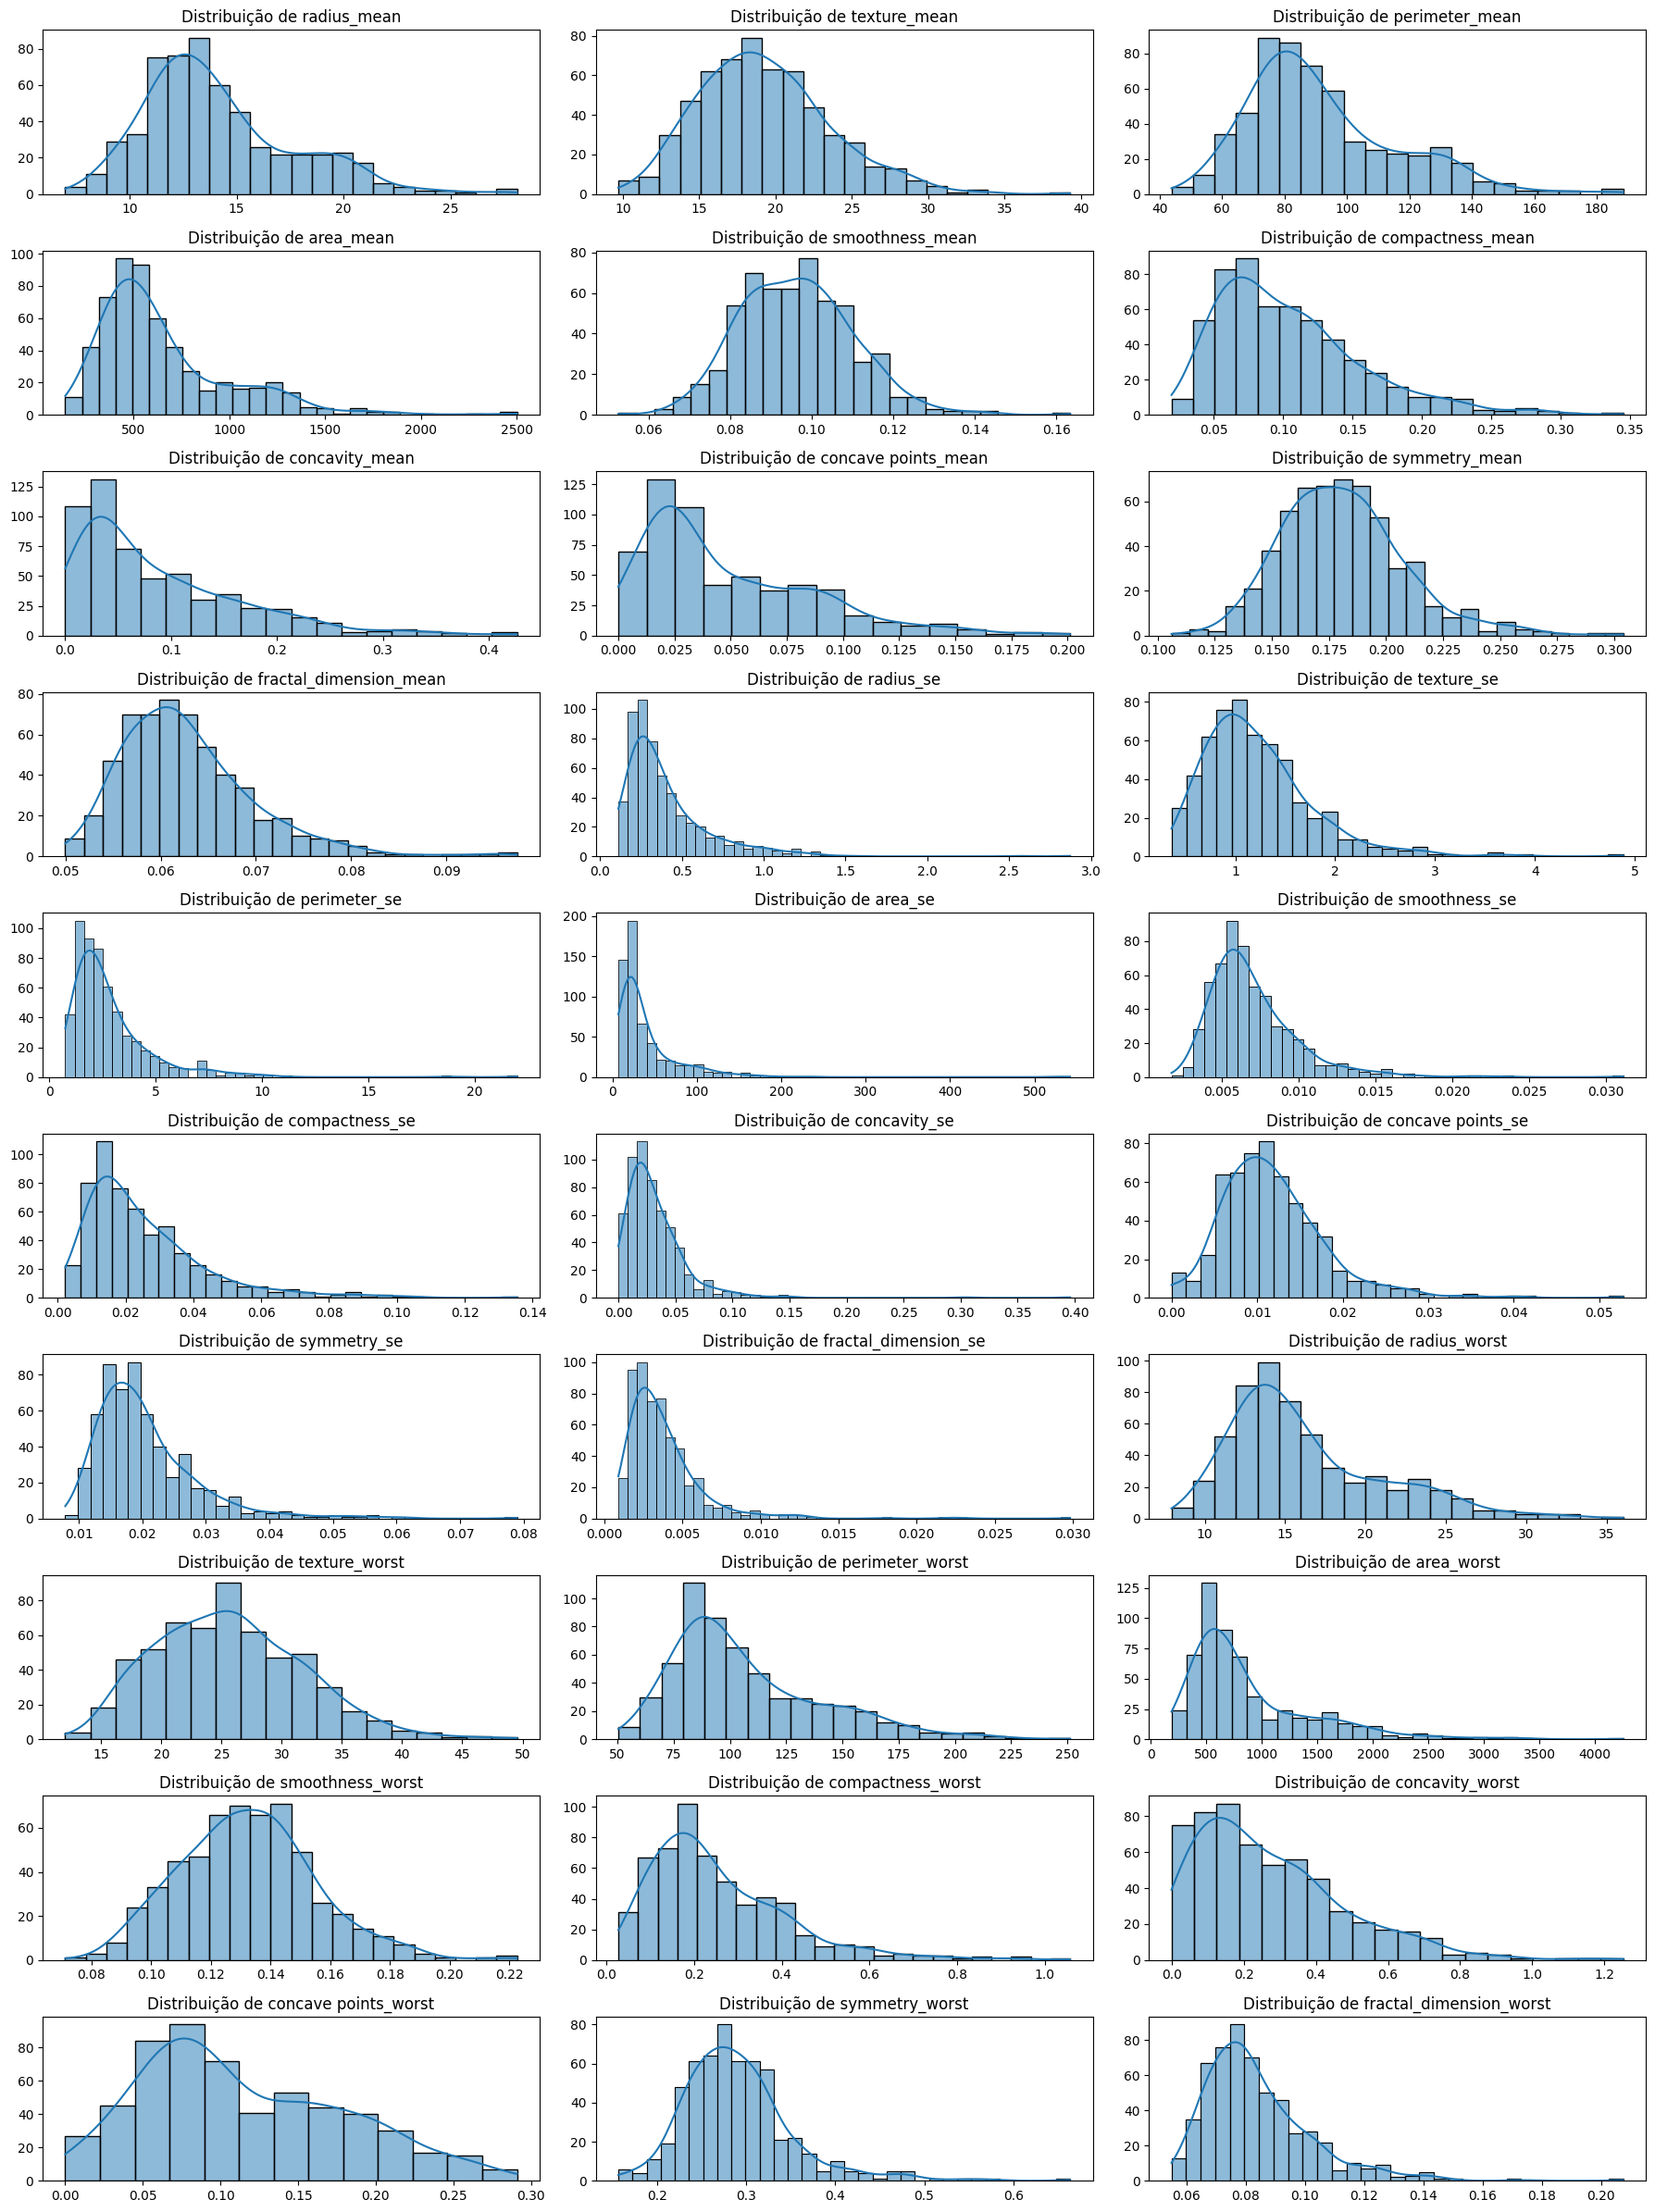

In [95]:
# Distribuição de várias features numéricas
# todas as features numéricas em grade

plt.figure(figsize=(18, 24))

for i, col in enumerate(numeric_features, start=1):
    plt.subplot(10, 3, i)
    sns.histplot(data=df_clean, x=col, kde=True)
    plt.title(f"Distribuição de {col}")
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

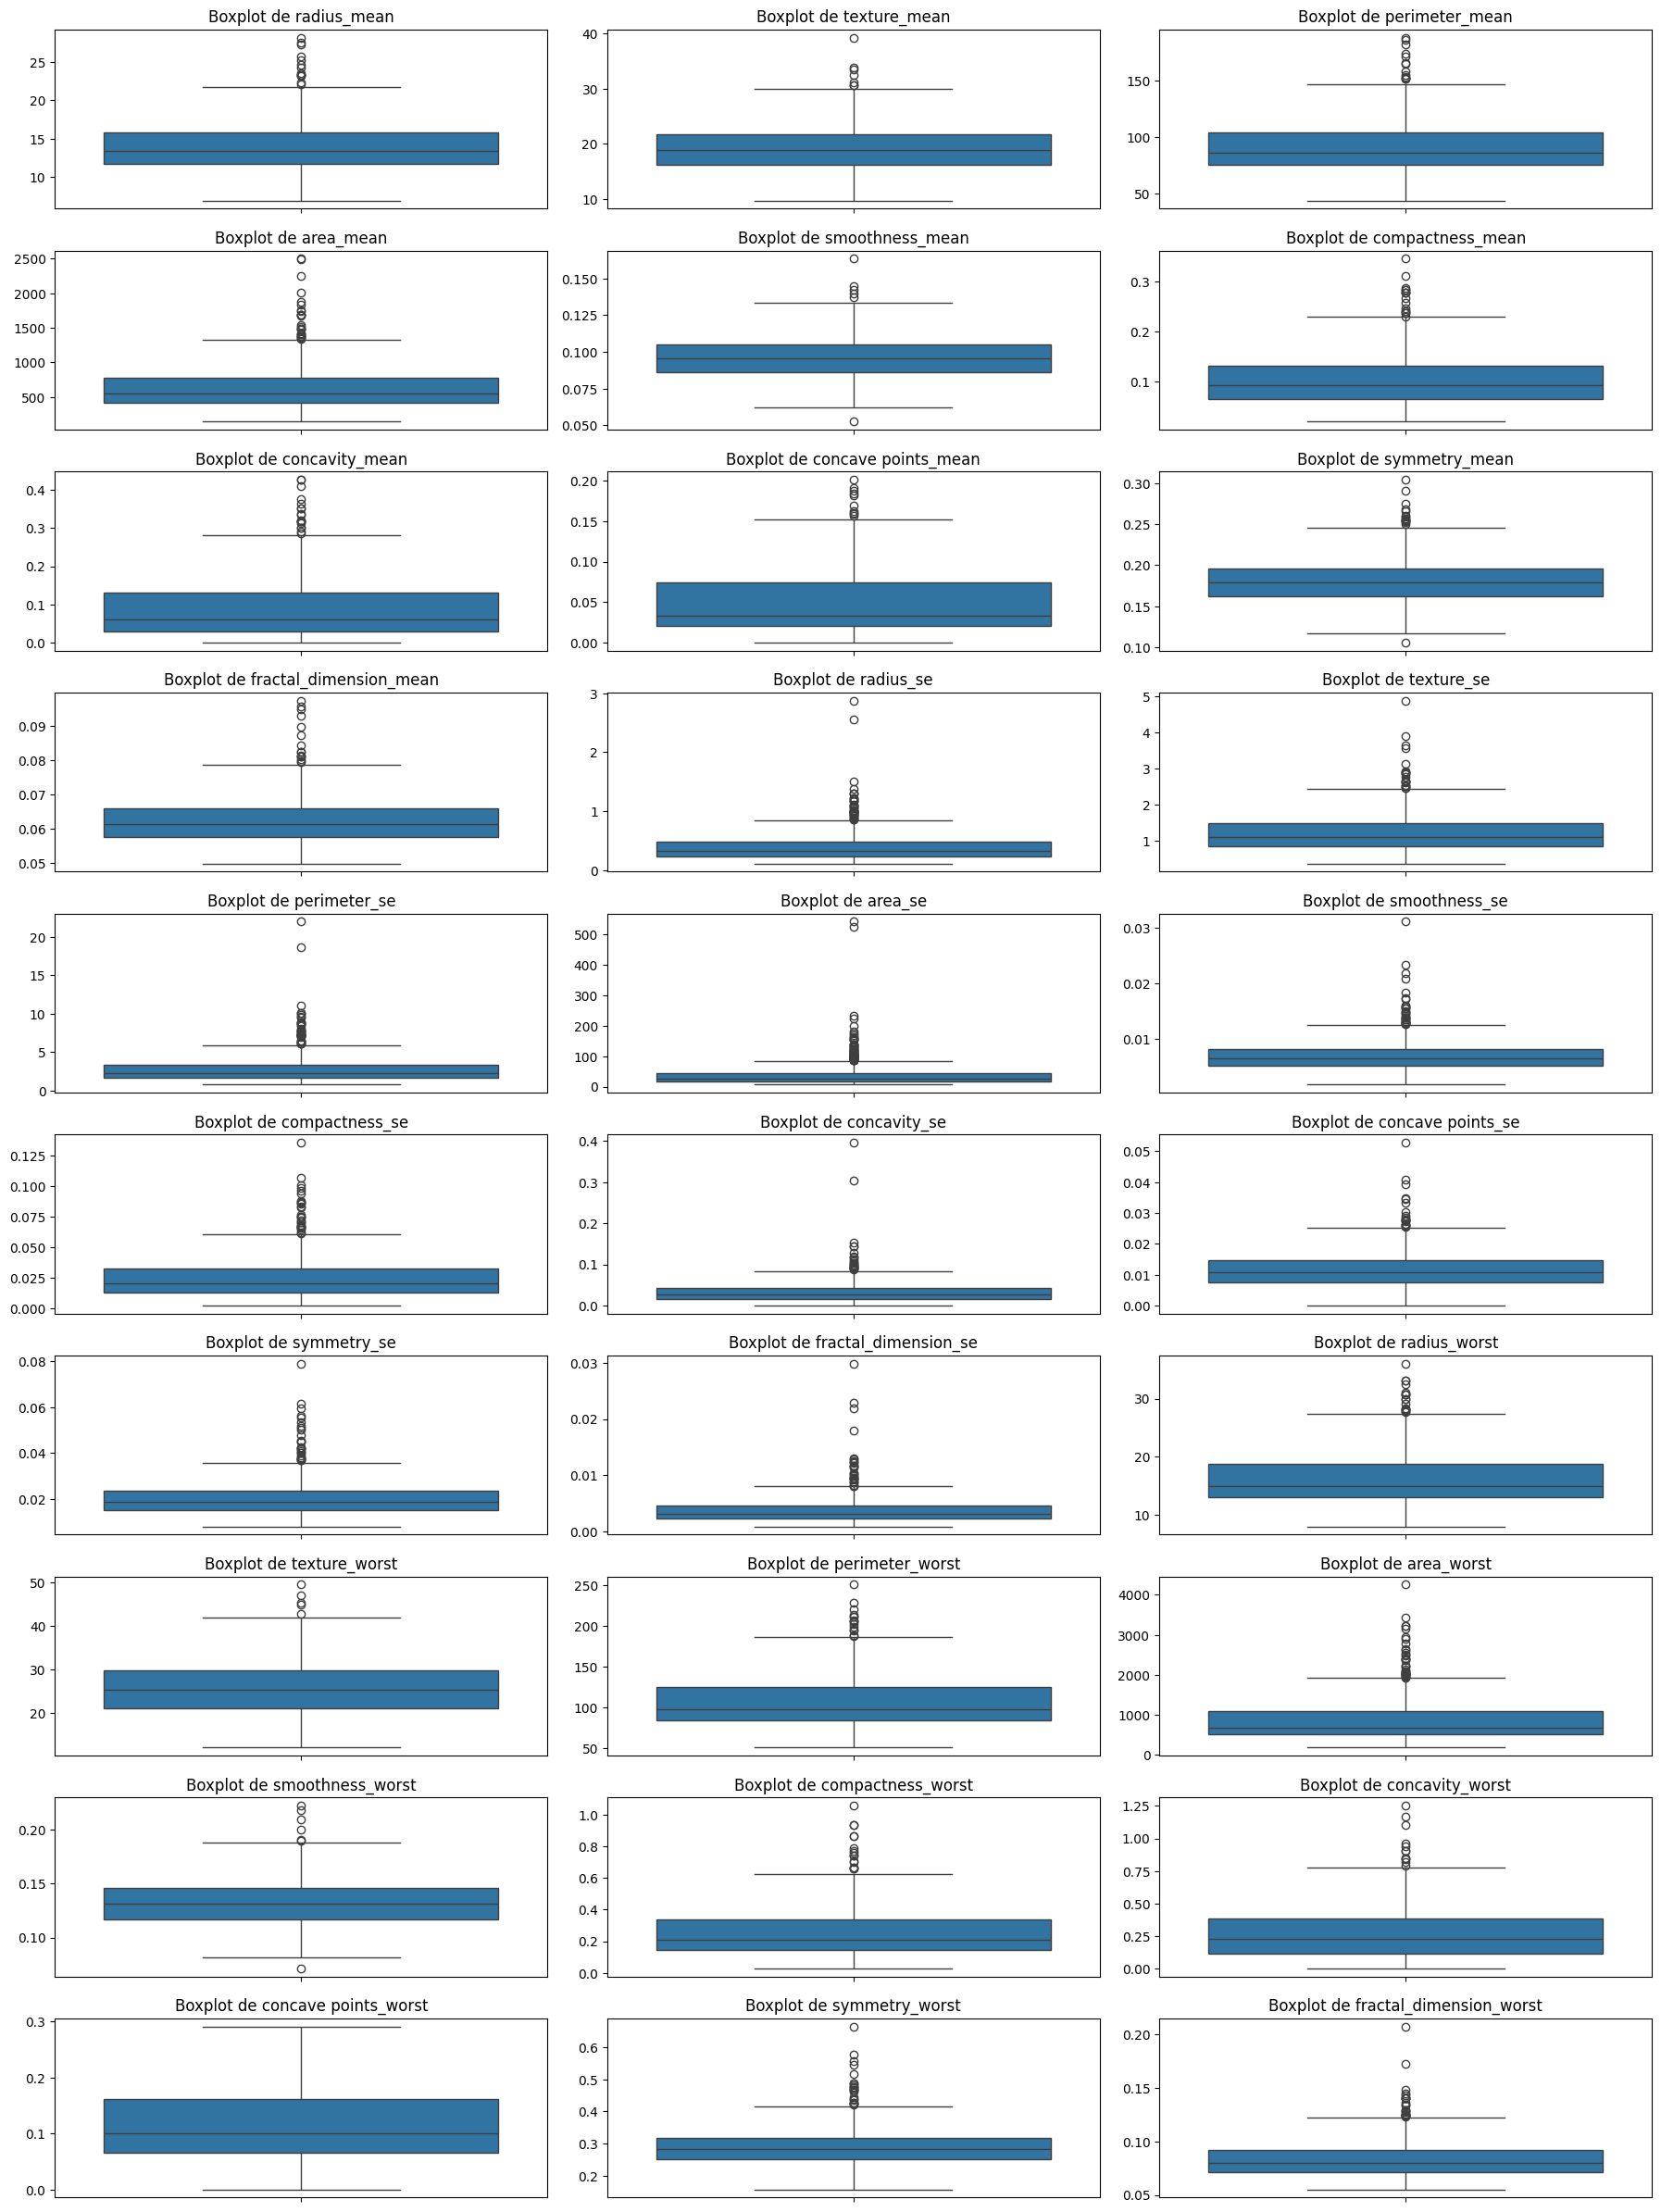

In [96]:
# Boxplot de várias features numéricas

plt.figure(figsize=(18, 24))

for i, col in enumerate(numeric_features, start=1):
    plt.subplot(10, 3, i)
    sns.boxplot(data=df_clean, y=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

In [97]:
## outliers

# Neste dataset, valores extremos não são removidos automaticamente
# Em bases médicas, valor extremo pode representar caso clínico importante


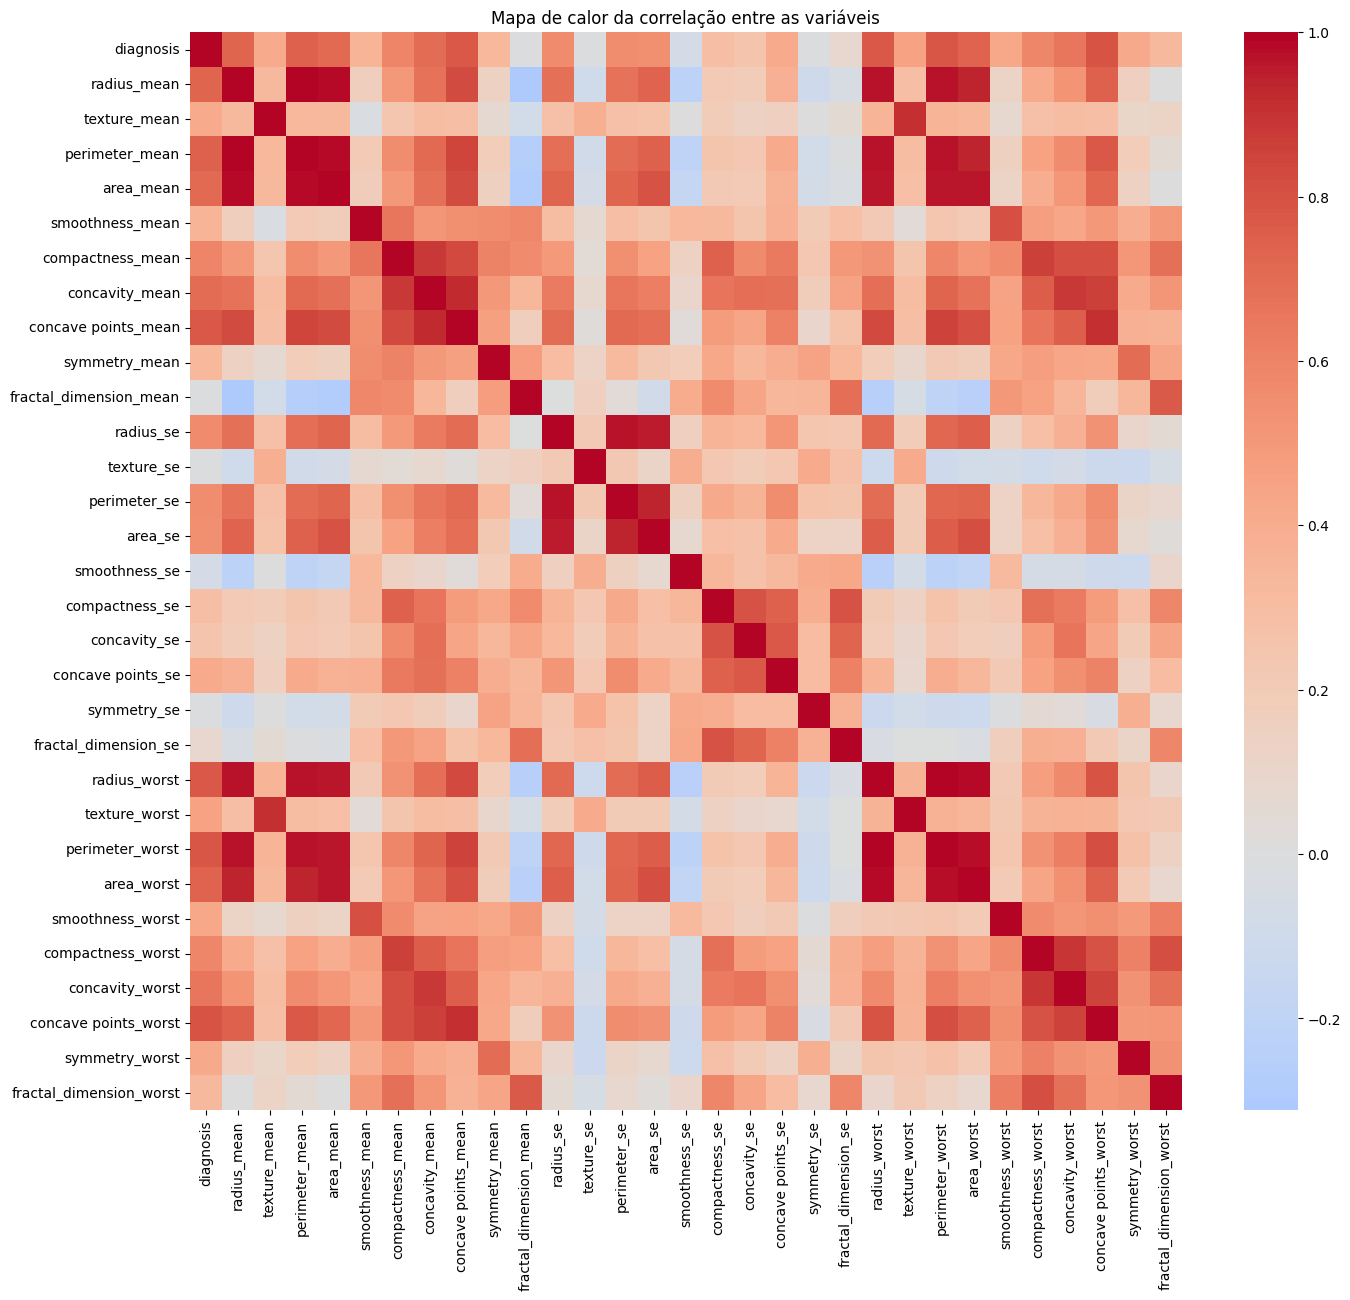

In [98]:
# Heatmap de correlação

# remover a coluna textual diagnosis_label, não participa da correlação numérica
corr = df_clean.drop(columns=["diagnosis_label"]).corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Mapa de calor da correlação entre as variáveis")
plt.show()

In [99]:
# No heatmap, alta correlação entre radius_mean, permiter_mean e area_mean - geometria

In [100]:
# Correlação de features com alvo

target_correlation = corr["diagnosis"].sort_values(ascending=False)

print("Correlação das variáveis com o alvo:")
display(target_correlation)

Correlação das variáveis com o alvo:


diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

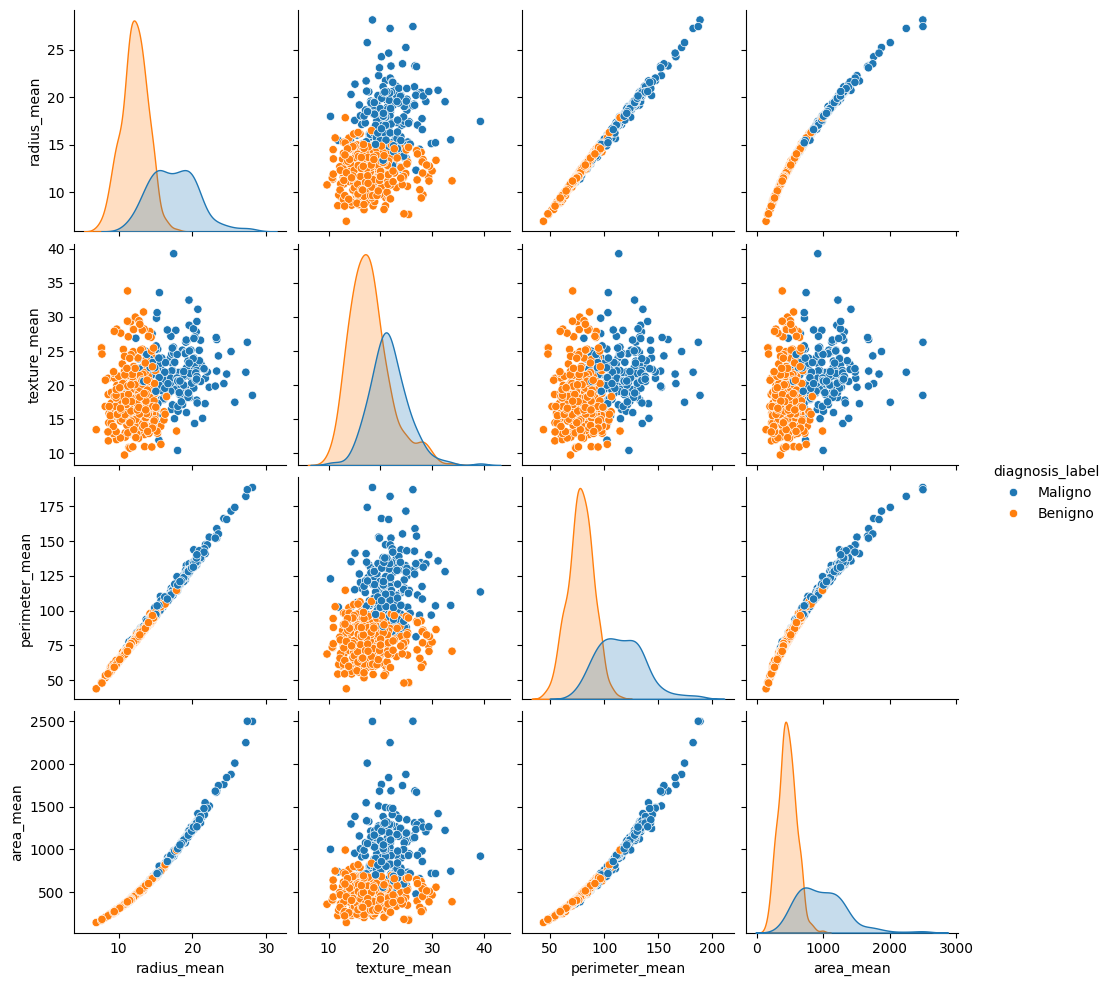

In [101]:
# Pairplot de variáveis selecionadas

# histogramas na diagonal, gráficos de dispersão fora da diagonal

colunas_pairplot = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "diagnosis_label"
]

sns.pairplot(df_clean[colunas_pairplot], hue="diagnosis_label")
plt.show()

In [102]:
# Separação visual clara entre features

In [103]:
# Split: treino / validação / teste (60/20/20)
# Treino - "aprende" padrões, ajusta parâmetros - encontrar a fórmula matemática que conecta features ao resultado
# Validação - comparar modelos sem "viciar" no teste - simulado, dado que não viu no treino mas usa para validar se aprendeu de verdade
# Teste - avaliação final, simula dados novos - prova oficial, só usa uma vez no final, nota final
#
# stratify=y:
# mantém a proporção de classes (0 e 1) parecida em todos os conjuntos
# Se 10% são Malignos - 10% de Malignos no Treino, 10% na Validação e 10% no Teste

# 60% treino, 20% validação, 20% teste

from sklearn.model_selection import train_test_split

# train_test_split - embaralha e divide em dois grupos - separar Teste (20%) e o restante (80%)
# X_trainval, y_trainval - 80% de dados para modelo, treino + validação
# X_teste, y_test - 20% de dados para teste

# X_trainval - dados que usaremos para treinar e ajustar o modelo
# X_test - para o "cofre", só será usado na avaliação final

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# Dos 80% restantes, separar 25% para Validação
# 25% de 80% é igual a 20% do total original, deixando 60% Treino e 20% Validação

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, 
    y_trainval, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_trainval
)

print(f"Dataset Original: {len(X)} amostras")
print("-" * 30)
print(f"Treino:     {X_train.shape[0]} amostras (60%)")
print(f"Validação:  {X_val.shape[0]} amostras (20%)")
print(f"Teste:      {X_test.shape[0]} amostras (20%)")

# Verificando se a proporção das classes se manteve (Garante que o Stratify funcionou)
print("\nProporção da classe alvo (Target) no Treino:")
print(y_train.value_counts(normalize=True))

Dataset Original: 569 amostras
------------------------------
Treino:     341 amostras (60%)
Validação:  114 amostras (20%)
Teste:      114 amostras (20%)

Proporção da classe alvo (Target) no Treino:
diagnosis
0    0.627566
1    0.372434
Name: proportion, dtype: float64


In [104]:
# Conferir balanceamento de classes

print("Proporção de classes no conjunto original:")
display(y.value_counts(normalize=True).round(4))

print("\nProporção de classes no treino:")
display(y_train.value_counts(normalize=True).round(4))

print("\nProporção de classes na validação:")
display(y_val.value_counts(normalize=True).round(4))

print("\nProporção de classes no teste:")
display(y_test.value_counts(normalize=True).round(4))

Proporção de classes no conjunto original:


diagnosis
0    0.6274
1    0.3726
Name: proportion, dtype: float64


Proporção de classes no treino:


diagnosis
0    0.6276
1    0.3724
Name: proportion, dtype: float64


Proporção de classes na validação:


diagnosis
0    0.6228
1    0.3772
Name: proportion, dtype: float64


Proporção de classes no teste:


diagnosis
0    0.6316
1    0.3684
Name: proportion, dtype: float64

In [105]:
# Tipos de features no treino

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Features numéricas:", len(numeric_features))
print(numeric_features)

print("\nFeatures categóricas:", len(categorical_features))
print(categorical_features)

Features numéricas: 30
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Features categóricas: 0
[]


In [106]:
# Pipeline de pré-processamento - linha de montagem de dados - Evita data leakage - modelo tem acesso indireto a informações do futuro (validação/teste)
# Modelo aprende algo que ele não deveria saber no momento da previsão

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Imputer - imputação de dados, substituir dados ausentes (NaN) por um valor estimado
# Mediana não é afetada por valores extremos, representa o “valor típico central”
# A média é puxada por outliers patológicos, mediana representa melhor a população

# Pipeline - sequencia ordenada de transformações, passos
# steps - lista de tuplas, cada tupla um passo da esteira
# pipeline transformer só será aplicado no fit/transform, lá será indicado o conjunto de dados

# Imputer deve ser feito somente sobre dados de treino para evitar Data Leakage
# Se houver um bilionário no conjunto de TESTE e calcularmos a mediana geral, o valor de TREINO será contaminado por essa fortuna
# A média sobe artificialmente (Data Leakage)
# Solução - separar treino e teste (bilionário vai para o teste e fica isolado), calculam fit só no treino (salários reais), preenche (transform) vazios do Teste usando a mediana do Treino
# Mediana representa a realidade da maioria (muitos estagiários x bilionário)

numeric_transformer_pipeline = Pipeline(steps=[
    
    # "imputer" - apelido, SimpleImputer - procura NaN, strategy = "median" - explica pelo que susbtituir
    # aplica mediana para dados faltantes nos dados faltantes (NaN) de treino/val/test
    ("imputer", SimpleImputer(strategy="median")),

    # "scaler" - equalizador, todas as colunas na mesma régua - Z = (x - u) / sigma - média 0 e desvio padrão 1
    ("scaler", StandardScaler())
])

# ColumnTransformer aplica transformações por tipo de coluna
# Implementa a lógica de Dividir, Transformar e Juntar (Split-Apply-Combine)
# transformerss é a lista de regras
# Fatia verticalmente - recorta apenas as colunas que estão na lista numeric_features, minidataset em memória
# preprocess - objeto que guarda a "receita do bolo", contém as instruções de transformação dos dados, roda com fit (aprender) ou transform (executar)

preprocess = ColumnTransformer(
    transformers=[
        # "num" - apelido - pega as colunas de numeric_features e aplica a pipeline numeric_transformer_pipeline
        # numeric_features - lista de colunas numéricas
        # numeric_transformer_pipeline - pipeline criada no passo anterior, especialista, tem imputer e scaler

        ("num", numeric_transformer_pipeline, numeric_features)
    ],

    # drop - joga fora colunas que não estão na lista numeric_features
    # Trava de segurança - Defensive Programming - evita que novas colunas adicionadas no futuro sejam processadas sem querer
    # Cenário de produção - dados chegam de sistemas externos 
    remainder="drop"
)

# desenho do diagrama iterativo da transformação de dados 
preprocess


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_na

In [107]:
# Modelo 1: Logistic Regression (baseline)
# Modelo clássico de classificação binária, interpretável (coeficientes), forte como baseline
# max_iter - número máximo de iterações do otimizador, aumenta para evitar erro de convergência

# conecta a "limpeza" com a "inteligência" (modelo matemático)
# Super Pipeline - recebe dado "sujo", limpa e dá diagnostico
# LogisticRegression - algoritmo de Classificação, responde perguntas Sim e Não
# tenta desenhar uma linha reta que separa melhor os pontos saudáveis dos pontos diabéticos por tentativa e erro
# Sigmoide - probabilidade entre 0 e 1

# class_weight - classe minoritária (doentes) tenha mesmo peso na decisão que classe majoritária (saudáveis)
# sem peso, errar saudável ou errar doente "custa" 1 ponto de penalidade para o algoritmo
# com peso, pagam multa se errar doente, preferimos "falso positivo" (suspeitar alguém saudável) do que "falso negativo"

from sklearn.linear_model import LogisticRegression

logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
        ))
])

logreg


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [108]:
# Modelo 2: Random Forest
# Captura relações não-lineares, lida bem com variáveis tabulares, costuma performar bem sem muito tuning
# Cria Centenas de Árvores de Decisão, para cada árvore dá um pedaço diferente dos dados e faz perguntas diferentes

# n_estimators - número de árvores, afeta estabilidade e velocidade
# class_weight="balanced" - ajusta penalização para lidar com desbalanceamento de classes, dá mais peso para a classe minoritária
# Se errar um caso de Breast Cancer rara toma penalidade muito maior do que se errar um caso Saudável
# random_state - sorteia quais colunas e quais pacientes vão para cada árvore

# max_depth - quantas perguntas a árvore pode fazer antes de dar uma resposta final
# none, árvore não tem limite de altura, cresce até todas as "folhas" (pontas finais) puras ou tenham pouquíssimos dados
# min_samples - mínima de amostras que um "nó" (ponto de decisão) deve ter para ser dividido em dois novos caminhos
# impede que árvore crie regras baseadas em grupos pequenos, evita que aprenda ruídos
# min_samples_leaf - quantidade mínima de amostras que deve existir em cada "folha"

from sklearn.ensemble import RandomForestClassifier

# Pipeline - random_forest é Pipeline objeto inteligente
random_forest = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        class_weight="balanced"
    ))
])

random_forest


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [109]:
# Treinamento dos modelos
# .fit(X, y) - executa o "aprendizado" com dados de treino, alfaiate costurando terno para servir naquele corpo específico

# algoritmo de Regressão Logística - recebe dados limpos, calcula coeficientes para desenhar a linha até convergir ou bater 2000 iterações
logreg.fit(X_train, y_train)

# algoritmo cria as árvores, cada árvore recebe pedaço dos dados limpos e cria nós de decisão
random_forest.fit(X_train, y_train)

print("Modelos treinados com sucesso.")


Modelos treinados com sucesso.


In [110]:
# Avaliação com métricas adequadas

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# accuracy - % de acertos gerais, pode enganar em desbalanceamento - quantos o modelo acertou
# precision - entre os previstos como 1, quantos eram realmente 1, falso positivo, Custo/Susto - quando diz que é doente, está certo ou não?
# recall (Revocação/Sensibilidade) - entre os 1 reais, quantos o modelo detectou - de todos que estão doentes, quantos o modelo encontrou - número mais importante para saude, baixo recall - falso negativo é validado pessoalmente
# f1 - média harmônica entre precision e recall, desempate

# Matriz de confusão - Y a realidade gabarito - X previsão do modelo
# inferior esquerdo - falso negativo - menor possível, preferencia 0

# funções e classes de sklearn.metrics, accuracy_score e precision_score funções matemáticas prontas
# ConfusionMatrixDisplay classe para criar objeto de exibição da matriz de confusão

# função para não precisar copiar e colar código toda vez que quiser testar um modelo
def evaluate_model(model_name, model, X_data, y_data):
    """
    - name - nome do modelo (string) para exibição
    - model - pipeline treinado (preprocess + modelo)
    - X_eval - features do conjunto de avaliação, y_eval target real do conjunto de avaliação
    """
    # .predict(X) gera as classes previstas (0 ou 1)
    # model vai receber a pipeline treinada (logreg ou random_forest) e gera lista de chutes (predictions)
    y_pred = model.predict(X_data)

    # Matriz de confusão - função pega o gabarito e a predição e conta falsos positivos, verdadeiros negativos e devolve matriz
    cm = confusion_matrix(y_data, y_pred)

    # Extração dos valores TN, FP, FN, TP
    # Ravel "achata" a matriz para pegar os 4 valores
    # TN (True Negative) - modelo diz "saudável" e a pessoa está saudável - Acerto ✅
    # FP (False Positive) - modelo diz "doente" mas pessoa está saudável - Erro Tipo I ⚠️ - Alarme falso
    # FN (False Negative) - modelo diz  "saudável", mas a pessoa está doente - Erro Tipo II 🚨 - mais perigoso na saúde!
    # TP (True Positive) - modelo diz "doente" e a pessoa está doente - Acerto ✅
    tn, fp, fn, tp = cm.ravel()

    # Specificity = capacidade de reconhecer negativos corretamente
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_data, y_pred),
        "precision": precision_score(y_data, y_pred, zero_division=0),
        "recall": recall_score(y_data, y_pred, zero_division=0),
        "f1": f1_score(y_data, y_pred, zero_division=0),
        "specificity": specificity
    }

    # Relatório Textual Completo
    print(f"\n" + "="*20 + f" {model_name} " + "="*20)
    print(classification_report(y_data, y_pred, zero_division=0))
    print(f"Specificity: {specificity:.4f}")

    # Visualização Profissional
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=['Pred. Benigno', 'Pred. Maligno'],
                yticklabels=['Real Benigno', 'Real Maligno'])
    plt.title(f"Matriz de Confusão — {model_name}")
    plt.ylabel("Realidade")
    plt.xlabel("Previsão do Modelo")
    plt.show()

    return results    



==================== Logistic Regression (VAL) ====================
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Specificity: 0.9718


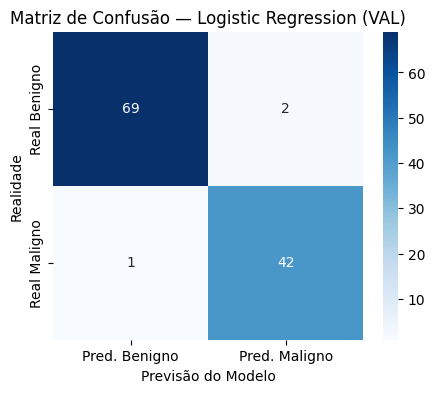


==================== Random Forest (VAL) ====================
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Specificity: 0.9859


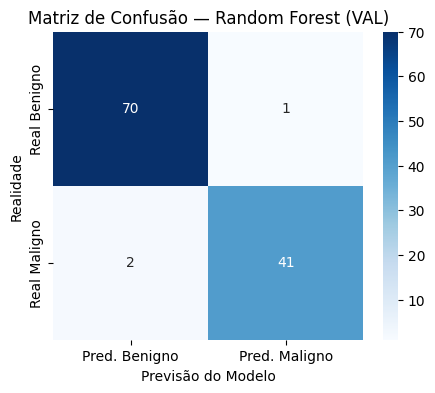

Comparação dos modelos na validação:


,model,accuracy,precision,recall,f1,specificity
0,Logistic Regression (VAL),0.973684,0.954545,0.976744,0.965517,0.971831
1,Random Forest (VAL),0.973684,0.976190,0.953488,0.964706,0.985915


In [111]:
# Avaliação na validação (escolha de modelo)

# organizando os resultados para comparar quem foi melhor
# cria lista vazia do Python, roda processo evaluate_model (prova, gráfico) e entrega Dicionário com as notas acc, prec, rec, f1
# append - adiciona item no final da lista

val_results = []

val_results.append(evaluate_model(
    "Logistic Regression (VAL)",
    logreg,
    X_val,
    y_val
))

val_results.append(evaluate_model(
    "Random Forest (VAL)",
    random_forest,
    X_val,
    y_val
))

val_df = pd.DataFrame(val_results).sort_values(by="f1", ascending=False)

print("Comparação dos modelos na validação:")
display(val_df)

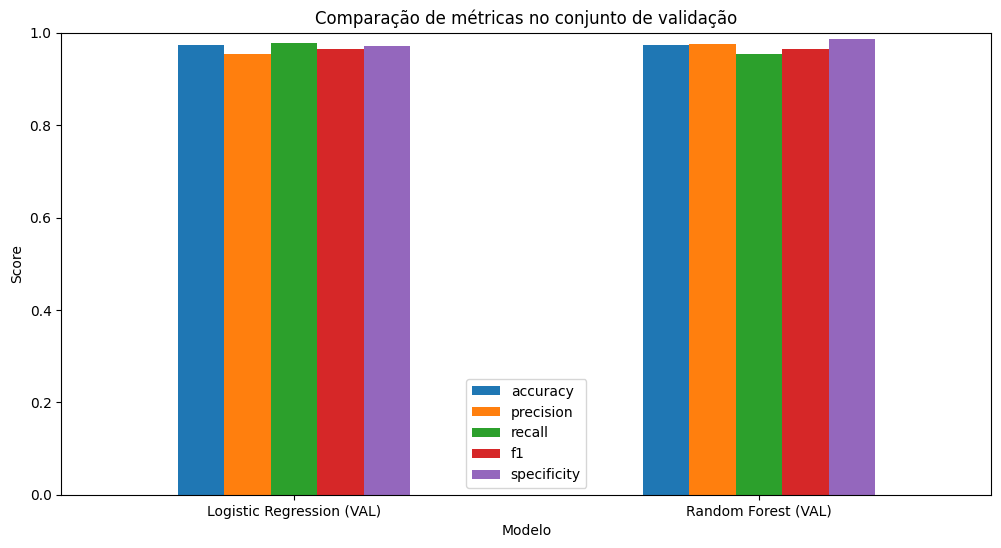

In [112]:
# Comparação Visual

metrics_to_plot = ["accuracy", "precision", "recall", "f1", "specificity"]

plot_df = val_df.set_index("model")[metrics_to_plot]

plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Comparação de métricas no conjunto de validação")
plt.ylabel("Score")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

In [113]:
# Interpretação do modelo

# --- Logistic Regression: coeficientes ---
# Coeficientes positivos aumentam probabilidade de Outcome=1
# Coeficientes negativos diminuem

# logreg é pipeline, acessa modelo "model" - definido cmo LogisticRegression
# coef_ - atributo onde pesos ficam guardados após o treino
# pesos numa lista dentro de outra lista - [0] pega a primeira linha, que é a única que interessa
# named_steps - atributo, funciona como dicionário python, pertence à classe Pipeline que tem vários named_steps identificados por nome
# Acesse o inventário e me entregue o objeto que está guardado com a etiqueta 'model' - chave do dicionário

lr_model = logreg.named_steps["model"]
coefs = lr_model.coef_[0]

# coef_df - recebe transformação dos números em Dataframe, associa nome da coluna ao peso dela
# abs - valor absoluto, importa mais peso do que o sinal - ou +
# ordena do maior para o menor

coef_df = pd.DataFrame({"feature": numeric_features, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df.sort_values("abs_coef", ascending=False).head(10)


,feature,coef,abs_coef
21,texture_worst,1.362726,1.362726
10,radius_se,1.141055,1.141055
7,concave points_mean,1.122813,1.122813
28,symmetry_worst,0.980219,0.980219
15,compactness_se,-0.828874,0.828874
13,area_se,0.828137,0.828137
26,concavity_worst,0.815070,0.815070
20,radius_worst,0.799605,0.799605
23,area_worst,0.786143,0.786143
6,concavity_mean,0.746066,0.746066


In [114]:
# XGBoost para classificação (ex.: sim/não) em dados tabulares

# XGBoost = "Gradient Boosted Decision Trees"
# treina muitas árvores pequenas, uma após a outra, nova árvore tenta corrigir os erros das anteriores
# forte para dados tabulares, dataset é tabular (colunas numéricas)
# Captura relações não lineares (ex.: combinação de features pode ser pior do que cada uma sozinha)
# Funciona bem com escalas diferentes (não precisa de StandardScaler como redes neurais/SVM).
# importa ordem/threshold das features, e árvores não dependem de distância/gradiente como modelos lineares
# imputação NaN sem scaler

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# XGBClassifier - classe com método .fit para treinar e .predict para prever, vem da biblioteca xgboost e não sklearn
from xgboost import XGBClassifier

# classification_report - tabela de texto pronta com tudo calculado
# roc_auc_score - Nota de Ranqueamento - Area Under the Receiver Operating Characteristic Curve - chance do modelo dar uma nota maior para o doente
# 0.5 - moeda, 1.0 perfeito, > 0.8 excelente


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Bibliotecas para XGBoost importadas com sucesso!")


Bibliotecas para XGBoost importadas com sucesso!


In [115]:
# Splits e Configuração do Pré-processador para XGBoost

# Pré-processamento para XGBoost - como todas as features são numéricas, apenas imputação de missing

# Aprende a mediana dos dados de treino (strategy="median" e preenche NaN (SimpleImputer)
xgb_imputer = SimpleImputer(strategy="median")

# Aprende a imputação no treino
X_train_xgb = xgb_imputer.fit_transform(X_train)
X_val_xgb = xgb_imputer.transform(X_val)
X_test_xgb = xgb_imputer.transform(X_test)

print("Dados preparados para XGBoost.")
print("Treino:", X_train_xgb.shape)
print("Validação:", X_val_xgb.shape)
print("Teste:", X_test_xgb.shape)

Dados preparados para XGBoost.
Treino: (341, 30)
Validação: (114, 30)
Teste: (114, 30)


In [116]:
# Configuração do Modelo XGBoost

# Cálculo do scale_pos_weight para balanceamento automático
# Se 90% saudáveis, ele aprende rápido a dizer "Saudável" para tudo e acerta 90% das vezes
# Cada erro que cometer num DOENTE (Positivo) vai custar 9 vezes mais na nota do que um erro num saudável

neg = (y_train == 0).sum()  # Conta quantos Saudáveis tem
pos = (y_train == 1).sum()  # Conta quantos Doentes tem
scale_pos_weight = neg / max(pos, 1) # Resultado, evita divisão por zero

print(f"Peso da classe positiva (scale_pos_weight): {scale_pos_weight:.2f}")

# Definição do Modelo com hiperparâmetros
xgb_model = XGBClassifier(
    n_estimators=800,           # Máximo de árvores (para antes com early stopping)
    learning_rate=0.03,         # Passo pequeno para melhor generalização - alto é 0.3
    max_depth=4,                # Complexidade da árvore, muito profunda, muito grande gera overfitting - 3 a 6 o ideal para dados tabulares
    min_child_weight=2,         # Não cria regra específica para grupo de apenas 1 indivíduo
    subsample=0.8,              # Para cada árvore, sorteia 80% dos dados - linhas e colunas, evita vício nas mesmas colunas e indivíduos
    colsample_bytree=0.8,
    gamma=0.1,                  #frio matemático para criar novos nós, evita overfitting
    reg_lambda=1.0, 
    objective="binary:logistic",    # classificação binária
    eval_metric="auc",              # AUC (Area Under Curve) - mede qualidade do Ranking, das pessoas que dei nota alta de risco, a maioria realmente está doente?
    scale_pos_weight=scale_pos_weight,  # liga modo de atenção
    random_state=42,
    n_jobs=-1,                       # usa todos os núcleos do processador para acelerar
    early_stopping_rounds=50  # Para se não melhorar após 50 árvores
)

# Criação do Pipeline Final - clf = CLassiFier, guarda o modelo treinado
xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb_model)
])

print("Modelo XGBoost instanciado.")


Peso da classe positiva (scale_pos_weight): 1.69
Modelo XGBoost instanciado.


In [117]:
# Treinamento com Early Stopping
# passar os dados de validação já transformados para o parâmetro eval_set
# necessário quando se usa Pipeline + XGBoost

# treina Pipeline xgb_model mas passando ordens para XGBoost dentro
# model__ eval_set - calcula o erro no Treino e na Validação após cada árvore criada
# verbose - imprime linhas na tela - train auc

xgb_model.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)

print("Treinamento concluído.")

# Mostra em qual iteração ele parou (melhor resultado)
# índice exato de onde o modelo estava no seu auge de inteligência
print("Melhor iteração:", xgb_model.best_iteration)

Treinamento concluído.
Melhor iteração: 184


In [118]:
# Avaliação no Teste

# Probabilidades - calcula uma confiança (probabilidade)
# predict_proba - duas colunas para cada paciente, chance de ser saudável (0) e chance de ser doente (1)
# [:, 1] - pega todas as linhas (:) da segunda coluna (1) - lista só com as probabilidades de doença

y_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

# Decisão com threshold padrão (0.5)
# >= 0.50 - True - astype - True vira 1, False vira 0
y_pred_xgb = (y_proba_xgb >= 0.50).astype(int)

cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()
specificity_xgb = tn / (tn + fp)

print("=== XGBoost (TEST) ===")
print(classification_report(y_test, y_pred_xgb, zero_division=0))
print(f"Specificity: {specificity_xgb:.4f}")

=== XGBoost (TEST) ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Specificity: 1.0000


In [119]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

def evaluate_model_full(model_name, y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    return results

In [120]:
# Tabela final de cmoparação

# Logistic Regression
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]
y_pred_logreg = (y_proba_logreg >= 0.50).astype(int)

# Random Forest
y_proba_rf = random_forest.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf >= 0.50).astype(int)

# XGBoost
y_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.50).astype(int)

final_results = []

final_results.append(evaluate_model_full(
    "Logistic Regression",
    y_test,
    y_pred_logreg,
    y_proba_logreg
))

final_results.append(evaluate_model_full(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_proba_rf
))

final_results.append(evaluate_model_full(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_proba_xgb
))

final_df = pd.DataFrame(final_results).sort_values(
    by=["recall", "f1", "roc_auc"],
    ascending=False
)

display(final_df)

,model,accuracy,precision,recall,f1,specificity,roc_auc,pr_auc,tn,fp,fn,tp
0,Logistic Regression,0.973684,0.953488,0.976190,0.964706,0.972222,0.995370,0.993561,70,2,1,41
2,XGBoost,0.982456,1.000000,0.952381,0.975610,1.000000,0.996032,0.994709,72,0,2,40
1,Random Forest,0.956140,0.974359,0.904762,0.938272,0.986111,0.997685,0.996187,71,1,4,38


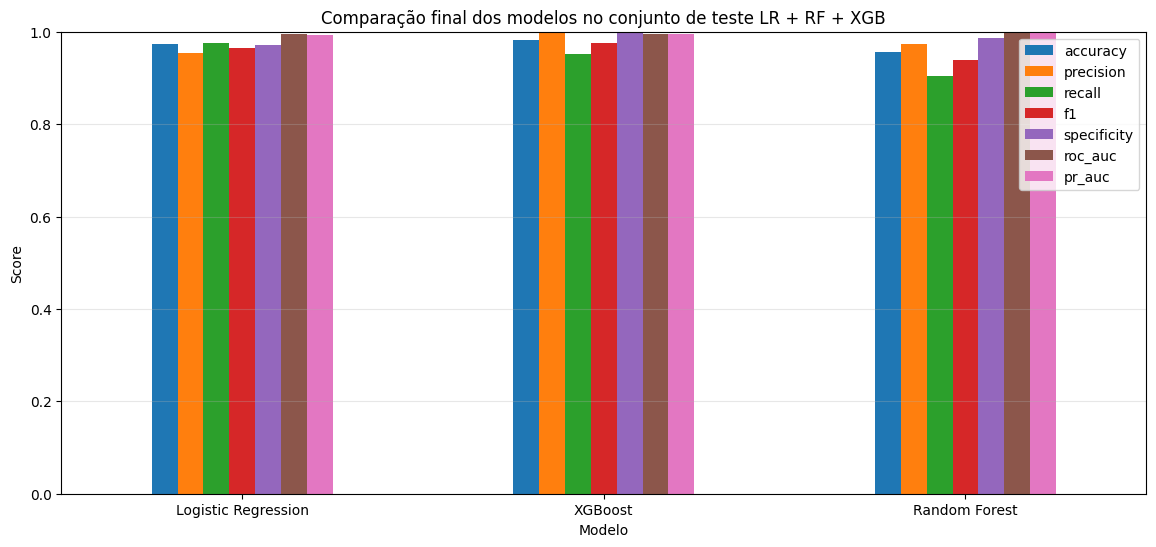

In [121]:
# Gráfico final de métricas de comparação

metrics_to_plot = ["accuracy", "precision", "recall", "f1", "specificity", "roc_auc", "pr_auc"]

plot_df = final_df.set_index("model")[metrics_to_plot]

plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("Comparação final dos modelos no conjunto de teste LR + RF + XGB")
plt.ylabel("Score")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

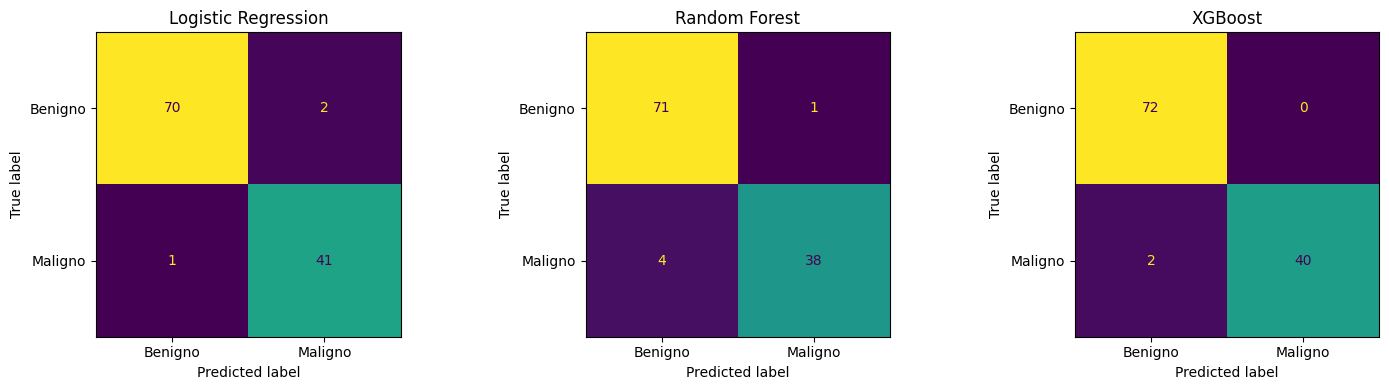


=== Logistic Regression ===
TN (Benigno → Benigno): 70
FP (Benigno → Maligno): 2
FN (Maligno → Benigno): 1
TP (Maligno → Maligno): 41

Interpretação:
- Falsos Negativos (FN): 1 → casos malignos NÃO detectados ⚠️
- Falsos Positivos (FP): 2 → alarmes falsos

=== Random Forest ===
TN (Benigno → Benigno): 71
FP (Benigno → Maligno): 1
FN (Maligno → Benigno): 4
TP (Maligno → Maligno): 38

Interpretação:
- Falsos Negativos (FN): 4 → casos malignos NÃO detectados ⚠️
- Falsos Positivos (FP): 1 → alarmes falsos

=== XGBoost ===
TN (Benigno → Benigno): 72
FP (Benigno → Maligno): 0
FN (Maligno → Benigno): 2
TP (Maligno → Maligno): 40

Interpretação:
- Falsos Negativos (FN): 2 → casos malignos NÃO detectados ⚠️
- Falsos Positivos (FP): 0 → alarmes falsos


In [ ]:
# Comparação de Matrizes de Confusão com XGB

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_info = [
    ("Logistic Regression", y_pred_logreg),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb)
]

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benigno", "Maligno"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [125]:
# Interpretação da Matriz de Confusão
def explain_confusion_matrix(cm, model_name):
    tn, fp, fn, tp = cm.ravel()

    print(f"\n=== {model_name} ===")
    print(f"TN (Benigno → Benigno): {tn}")
    print(f"FP (Benigno → Maligno): {fp}")
    print(f"FN (Maligno → Benigno): {fn}")
    print(f"TP (Maligno → Maligno): {tp}")

    print("\nInterpretação:")
    print(f"- Falsos Negativos (FN): {fn} → casos malignos NÃO detectados ⚠️")
    print(f"- Falsos Positivos (FP): {fp} → alarmes falsos")

cm_log = confusion_matrix(y_test, y_pred_logreg)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

explain_confusion_matrix(cm_log, "Logistic Regression")
explain_confusion_matrix(cm_rf, "Random Forest")
explain_confusion_matrix(cm_xgb, "XGBoost")



=== Logistic Regression ===
TN (Benigno → Benigno): 70
FP (Benigno → Maligno): 2
FN (Maligno → Benigno): 1
TP (Maligno → Maligno): 41

Interpretação:
- Falsos Negativos (FN): 1 → casos malignos NÃO detectados ⚠️
- Falsos Positivos (FP): 2 → alarmes falsos

=== Random Forest ===
TN (Benigno → Benigno): 71
FP (Benigno → Maligno): 1
FN (Maligno → Benigno): 4
TP (Maligno → Maligno): 38

Interpretação:
- Falsos Negativos (FN): 4 → casos malignos NÃO detectados ⚠️
- Falsos Positivos (FP): 1 → alarmes falsos

=== XGBoost ===
TN (Benigno → Benigno): 72
FP (Benigno → Maligno): 0
FN (Maligno → Benigno): 2
TP (Maligno → Maligno): 40

Interpretação:
- Falsos Negativos (FN): 2 → casos malignos NÃO detectados ⚠️
- Falsos Positivos (FP): 0 → alarmes falsos


In [ ]:
# Quadro de métricas finais

final_results = []

final_results.append(evaluate_model_full(
    "Logistic Regression",
    y_test,
    y_pred_logreg,
    y_proba_logreg
))

final_results.append(evaluate_model_full(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_proba_rf
))

final_results.append(evaluate_model_full(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_proba_xgb
))

final_df = pd.DataFrame(final_results)

# Ordena priorizando recall (critério clínico)
final_df = final_df.sort_values(
    by=["recall", "f1", "roc_auc"],
    ascending=False
)

display(final_df)

# Custo Clinico - quantificar o impacto dos erros do modelo na saúde
def custo_clinico(fn, fp, peso_fn=10, peso_fp=1):
    return fn * peso_fn + fp * peso_fp

final_df["clinical_cost"] = final_df.apply(
    lambda row: custo_clinico(row["fn"], row["fp"]),
    axis=1
)

display(final_df.sort_values(by="clinical_cost"))

,model,accuracy,precision,recall,f1,specificity,roc_auc,pr_auc,tn,fp,fn,tp
0,Logistic Regression,0.973684,0.953488,0.976190,0.964706,0.972222,0.995370,0.993561,70,2,1,41
2,XGBoost,0.982456,1.000000,0.952381,0.975610,1.000000,0.996032,0.994709,72,0,2,40
1,Random Forest,0.956140,0.974359,0.904762,0.938272,0.986111,0.997685,0.996187,71,1,4,38


In [ ]:
# Matriz de confusão mostrou que Logistic Regression apresentou o menor número de falsos negativos (FN=1)
# mais adequada para cenários onde a detecção de casos malignos é crítica

# Random Forest com FN = 4 teve pior desempenho clínico com tendência a perder casos malignos
# XGBoost teve melhor equilíbrio melhor equilíbrio geral entre métricas

# Acurácia teve valores elevados em todos os modelos (≈97%)
# Métrica mais crítica é recall (sensibilidade), pois falsos negativos representam casos malignos não detectados

#       model	            accuracy	precision	recall	    f1	        specificity	roc_auc	    pr_auc	    tn	fp	fn	tp
#   0	Logistic Regression	0.973684	0.953488	0.976190	0.964706	0.972222	0.995370	0.993561	70	2	1	41
#   1	Random Forest	    0.956140	0.974359	0.904762	0.938272	0.986111	0.997685	0.996187	71	1	4	38
#   2	XGBoost	            0.982456	1.000000	0.952381	0.975610	1.000000	0.996032	0.994709	72	0	2	40








,model,accuracy,precision,recall,f1,specificity,roc_auc,pr_auc,tn,fp,fn,tp,clinical_cost
0,Logistic Regression,0.973684,0.953488,0.976190,0.964706,0.972222,0.995370,0.993561,70,2,1,41,12
2,XGBoost,0.982456,1.000000,0.952381,0.975610,1.000000,0.996032,0.994709,72,0,2,40,20
1,Random Forest,0.956140,0.974359,0.904762,0.938272,0.986111,0.997685,0.996187,71,1,4,38,41
